In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k Dataset (1) (1).csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'simple_placement_dataset.csv',
 'movies_dataset(1).csv',
 'WineQT.csv',
 'WineQT_Feature_Engineered.csv',
 'placement_predict_50k_adjusted (1).csv',
 'student_data.csv',
 'xgboost_lightgbm_shap_student_dataset.csv',
 'iris_dataset.csv',
 'breast_cancer_classification_dataset (1).csv',
 'mall_customers_clustering_dataset.csv',
 'digits_pca_tsne_umap_dataset.csv',
 'isolation_forest_dataset.csv',
 'socioeconomic_profiling_dataset.csv',
 'ml_cross_validation_calibration_dataset.csv',
 'hyperparameter_tuning_dataset.csv',
 'evaluation_threshold_calibration_dataset.csv']

In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')

First 5 rows:
   study_hours  attendance  assignment_score  test_score  sleep_hours  \
0         1.00       98.94             68.59       44.31         9.60   
1         3.02       85.35             58.97       47.75         8.75   
2         1.00       98.59             78.97       34.69         8.89   
3         2.98       50.00             96.40       67.84         7.79   
4         3.07       50.20             95.23       58.18         8.47   

   practice_score  previous_score  revision_hours  passed  
0           49.42           72.26            3.69       0  
1           75.07           77.63            5.55       0  
2           49.19           87.35            3.37       0  
3           65.27           66.57            5.74       0  
4           78.99           62.52            5.69       0  

Dataset Shape: (600, 9)

Class Distribution:
passed
0    357
1    243
Name: count, dtype: int64

Training samples: 360
Validation samples: 120
Test samples: 120

========== DEFAULT THRES

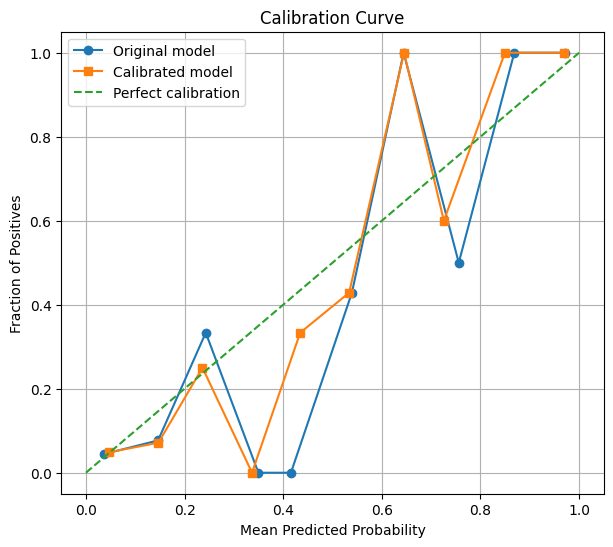

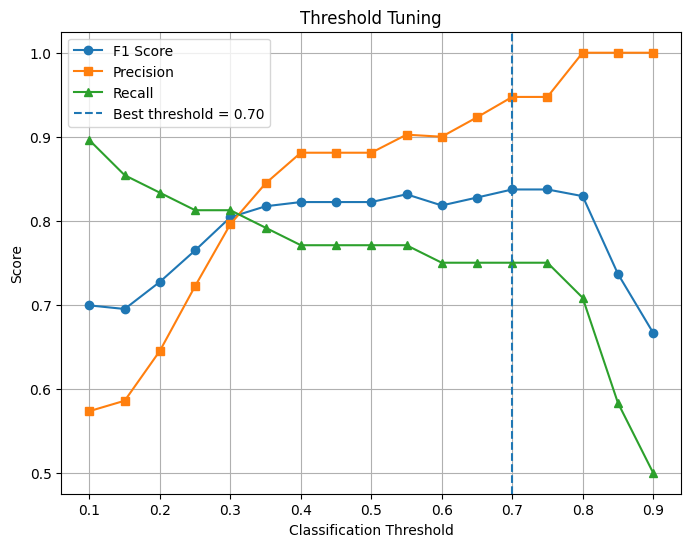

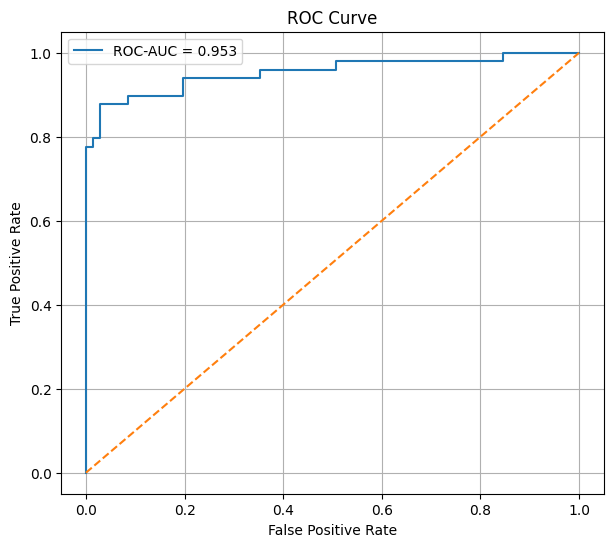


========== FINAL PROJECT SUMMARY ==========
                Metric    Value
     Default Threshold 0.500000
        Best Threshold 0.700000
          Test ROC-AUC 0.952860
         Test Log Loss 0.251221
      Test Brier Score 0.071228
   Calibrated Log Loss 0.257962
Calibrated Brier Score 0.072770


In [5]:
# Evaluation, Threshold Tuning, and Calibration Project
# Subject: Machine Learning
# Dataset: evaluation_threshold_calibration_dataset.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    log_loss,
    brier_score_loss,
    precision_recall_curve,
    roc_curve
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# ---------------------------------------------------------
# 1. Load Dataset
# ---------------------------------------------------------
df = pd.read_csv("/content/drive/MyDrive/Colab/evaluation_threshold_calibration_dataset.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nClass Distribution:")
print(df["passed"].value_counts())

# ---------------------------------------------------------
# 2. Features and Target
# ---------------------------------------------------------
X = df.drop("passed", axis=1)
y = df["passed"]

# ---------------------------------------------------------
# 3. Train / Validation / Test Split
# ---------------------------------------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

# ---------------------------------------------------------
# 4. Logistic Regression Model
# ---------------------------------------------------------
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

# ---------------------------------------------------------
# 5. Default Threshold = 0.50
# ---------------------------------------------------------
val_prob = model.predict_proba(X_val)[:, 1]
test_prob = model.predict_proba(X_test)[:, 1]

default_threshold = 0.50

val_pred_default = (val_prob >= default_threshold).astype(int)

print("\n========== DEFAULT THRESHOLD (0.50) ==========")
print(f"Accuracy : {accuracy_score(y_val, val_pred_default):.4f}")
print(f"Precision: {precision_score(y_val, val_pred_default):.4f}")
print(f"Recall   : {recall_score(y_val, val_pred_default):.4f}")
print(f"F1 Score : {f1_score(y_val, val_pred_default):.4f}")

# ---------------------------------------------------------
# 6. Evaluate Different Classification Thresholds
# ---------------------------------------------------------
thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:
    predictions = (val_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, predictions),
        "Precision": precision_score(
            y_val, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_val, predictions, zero_division=0
        ),
        "F1": f1_score(
            y_val, predictions, zero_division=0
        )
    })

threshold_results = pd.DataFrame(results)

print("\n========== THRESHOLD EVALUATION ==========")
print(threshold_results.to_string(index=False))

# ---------------------------------------------------------
# 7. Find Threshold with Highest F1 Score
# ---------------------------------------------------------
best_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_threshold = best_row["Threshold"]

print("\n========== BEST F1 THRESHOLD ==========")
print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1 Score : {best_row['F1']:.4f}")
print(f"Precision     : {best_row['Precision']:.4f}")
print(f"Recall        : {best_row['Recall']:.4f}")

# ---------------------------------------------------------
# 8. Evaluate Tuned Threshold on Test Set
# ---------------------------------------------------------
test_pred_tuned = (
    test_prob >= best_threshold
).astype(int)

print("\n========== TUNED THRESHOLD TEST RESULTS ==========")
print(f"Threshold: {best_threshold:.2f}")
print(f"Accuracy : {accuracy_score(y_test, test_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, test_pred_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, test_pred_tuned):.4f}")
print(f"F1 Score : {f1_score(y_test, test_pred_tuned):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, test_pred_tuned))

# ---------------------------------------------------------
# 9. ROC-AUC and Probability Metrics
# ---------------------------------------------------------
roc_auc = roc_auc_score(y_test, test_prob)
logloss = log_loss(y_test, test_prob)
brier = brier_score_loss(y_test, test_prob)

print("\n========== PROBABILITY METRICS ==========")
print(f"ROC-AUC    : {roc_auc:.4f}")
print(f"Log Loss   : {logloss:.4f}")
print(f"Brier Score: {brier:.4f}")

# ---------------------------------------------------------
# 10. Probability Calibration
# ---------------------------------------------------------
calibrated_model = CalibratedClassifierCV(
    estimator=model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train, y_train)

calibrated_test_prob = (
    calibrated_model.predict_proba(X_test)[:, 1]
)

calibrated_test_pred = (
    calibrated_test_prob >= best_threshold
).astype(int)

calibrated_logloss = log_loss(
    y_test,
    calibrated_test_prob
)

calibrated_brier = brier_score_loss(
    y_test,
    calibrated_test_prob
)

print("\n========== CALIBRATED MODEL ==========")
print(
    f"Accuracy : "
    f"{accuracy_score(y_test, calibrated_test_pred):.4f}"
)
print(
    f"Precision: "
    f"{precision_score(y_test, calibrated_test_pred):.4f}"
)
print(
    f"Recall   : "
    f"{recall_score(y_test, calibrated_test_pred):.4f}"
)
print(
    f"F1 Score : "
    f"{f1_score(y_test, calibrated_test_pred):.4f}"
)
print(
    f"Log Loss : "
    f"{calibrated_logloss:.4f}"
)
print(
    f"Brier Score: "
    f"{calibrated_brier:.4f}"
)

# ---------------------------------------------------------
# 11. Calibration Curve
# ---------------------------------------------------------
uncalibrated_true, uncalibrated_pred = calibration_curve(
    y_test,
    test_prob,
    n_bins=10,
    strategy="uniform"
)

calibrated_true, calibrated_pred = calibration_curve(
    y_test,
    calibrated_test_prob,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 6))

plt.plot(
    uncalibrated_pred,
    uncalibrated_true,
    marker="o",
    label="Original model"
)

plt.plot(
    calibrated_pred,
    calibrated_true,
    marker="s",
    label="Calibrated model"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 12. Threshold vs F1 / Precision / Recall
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1 Score"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="s",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="^",
    label="Recall"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 13. ROC Curve
# ---------------------------------------------------------
fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    test_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 14. Final Summary
# ---------------------------------------------------------
summary = pd.DataFrame({
    "Metric": [
        "Default Threshold",
        "Best Threshold",
        "Test ROC-AUC",
        "Test Log Loss",
        "Test Brier Score",
        "Calibrated Log Loss",
        "Calibrated Brier Score"
    ],
    "Value": [
        default_threshold,
        best_threshold,
        roc_auc,
        logloss,
        brier,
        calibrated_logloss,
        calibrated_brier
    ]
})

print("\n========== FINAL PROJECT SUMMARY ==========")
print(summary.to_string(index=False))